Epoch  1: loss = 0.6931, w = [0.14375 0.14375], b = 0.0000
Epoch  2: loss = 0.6227, w = [0.24548614 0.24548614], b = -0.0328
Epoch  3: loss = 0.5835, w = [0.32282793 0.32282793], b = -0.0837
Epoch  4: loss = 0.5562, w = [0.38554599 0.38554599], b = -0.1446
Epoch  5: loss = 0.5339, w = [0.43902453 0.43902453], b = -0.2108
Epoch  6: loss = 0.5142, w = [0.48637277 0.48637277], b = -0.2796
Epoch  7: loss = 0.4960, w = [0.52947276 0.52947276], b = -0.3497
Epoch  8: loss = 0.4791, w = [0.5695083 0.5695083], b = -0.4198
Epoch  9: loss = 0.4630, w = [0.60724695 0.60724695], b = -0.4895
Epoch 10: loss = 0.4478, w = [0.64319875 0.64319875], b = -0.5582
Epoch 11: loss = 0.4334, w = [0.6777098 0.6777098], b = -0.6259
Epoch 12: loss = 0.4196, w = [0.71101955 0.71101955], b = -0.6923
Epoch 13: loss = 0.4065, w = [0.74329686 0.74329686], b = -0.7573
Epoch 14: loss = 0.3941, w = [0.77466322 0.77466322], b = -0.8209
Epoch 15: loss = 0.3822, w = [0.805208 0.805208], b = -0.8831
Epoch 16: loss = 0.3708, 

/tmp/ipykernel_260/807922752.py:110: RuntimeWarning: invalid value encountered in scalar divide
  x_line = -b / w[0]


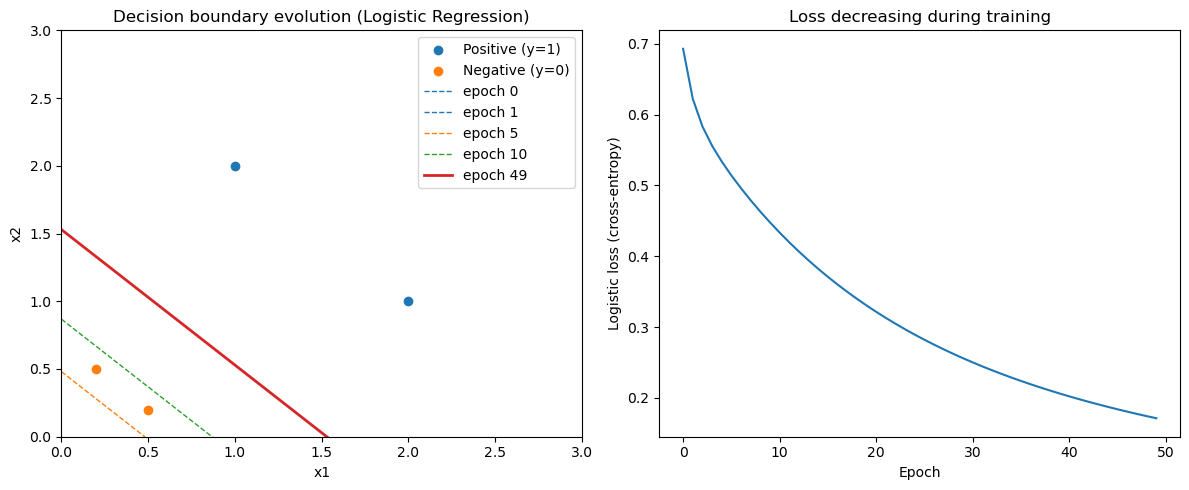

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Construct a simple binary classification dataset
# =========================

# positive（y = 1）
x_pos = np.array([[2, 1],
                  [1, 2]])

# negative（y = 0）
x_neg = np.array([[0.5, 0.2],
                  [0.2, 0.5]])

# Combined into a dataset
X = np.vstack([x_pos, x_neg])     # (4, 2)
y = np.array([1, 1, 0, 0])        # (4,)

# =========================
# 2. def sigmoid and loss
# =========================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_loss(X, y, w, b):
    """
    Average cross-entropy loss in binary logistic regression：
    L = - 1/n * sum( y log(p) + (1-y) log(1-p) )
    p = sigmoid(<w,x>+b)
    """
    z = X @ w + b
    p = sigmoid(z)
    # Add a very tiny number to prevent log(0) from being entered
    eps = 1e-8
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    return loss

# =========================
# 3. Gradient descent training Logistic Regression
# =========================

def train_logistic_regression(X, y, lr=0.5, epochs=50):
    n_samples, n_features = X.shape
    # Initialization parameters
    w = np.zeros(n_features)
    b = 0.0

    w_history = []
    b_history = []
    loss_history = []

    for epoch in range(epochs):
        # linear part
        z = X @ w + b           # (n_samples,)
        p = sigmoid(z)          # expect probability: p(y=1|x)

        # calculate loss
        loss = logistic_loss(X, y, w, b)

        # Record the current parameters and loss
        w_history.append(w.copy())
        b_history.append(b)
        loss_history.append(loss)

        # calculate gradient
        # dL/dw = 1/n * X^T (p - y)
        # dL/db = 1/n * sum(p - y)
        error = p - y           # (n_samples,)
        grad_w = X.T @ error / n_samples
        grad_b = np.sum(error) / n_samples

        # Gradient descent update
        w -= lr * grad_w
        b -= lr * grad_b

        # Print it out and observe the convergence.
        print(f"Epoch {epoch+1:2d}: loss = {loss:.4f}, w = {w}, b = {b:.4f}")

    return w, b, w_history, b_history, loss_history

# train model
w_learned, b_learned, w_hist, b_hist, loss_hist = train_logistic_regression(
    X, y, lr=0.5, epochs=50
)

print("\nFinal learned parameters:")
print("w =", w_learned)
print("b =", b_learned)

# =========================
# 4. Drawing tools: Decision boundary
# =========================

def plot_decision_boundary(ax, w, b, x_range=(0, 3), **kwargs):
    """
    for <w,x> + b = 0
    if x = (x1, x2)，then：
        w1 * x1 + w2 * x2 + b = 0
    →  x2 = -(w1 * x1 + b) / w2   (when w2 != 0)
    """
    x_vals = np.linspace(x_range[0], x_range[1], 100)

    if abs(w[1]) > 1e-8:
        y_vals = -(w[0] * x_vals + b) / w[1]
        ax.plot(x_vals, y_vals, **kwargs)
    else:
        # Extreme case: straight line vertical
        x_line = -b / w[0]
        ax.axvline(x_line, **kwargs)

# =========================
# 5. Visualization: Evolution of Decision Boundary + Loss Reduction
# =========================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ---- Left side: Data points + decision boundaries at different training stages ----

# Plot data points
ax1.scatter(x_pos[:, 0], x_pos[:, 1], label="Positive (y=1)")
ax1.scatter(x_neg[:, 0], x_neg[:, 1], label="Negative (y=0)")

# Select snapshots from several epochs to draw the decision boundary.
# Epoch = To review the entire training dataset and train the program once.
snapshot_epochs = [0, 1, 5, 10, len(w_hist) - 1]   # Early stage of training → Middle stage → Final stage

for idx in snapshot_epochs:
    w_snap = w_hist[idx]
    b_snap = b_hist[idx]
    label = f"epoch {idx}"
    # Different line types are used to distinguish
    if idx == snapshot_epochs[-1]:
        # Finally, emphasize with a solid line.
        plot_decision_boundary(ax1, w_snap, b_snap, x_range=(0, 3),
                               linestyle='-', linewidth=2, label=label)
    else:
        plot_decision_boundary(ax1, w_snap, b_snap, x_range=(0, 3),
                               linestyle='--', linewidth=1, label=label)

ax1.set_xlim(0, 3)
ax1.set_ylim(0, 3)
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_title("Decision boundary evolution (Logistic Regression)")
ax1.legend()

# ---- Right side: Loss decreases with epoch ----

epochs = np.arange(len(loss_hist))
ax2.plot(epochs, loss_hist)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Logistic loss (cross-entropy)")
ax2.set_title("Loss decreasing during training")

plt.tight_layout()
plt.show()
